# Final report — theory parameter sweeps (2026-08-12)

Bare-bones QDHT sweeps showing how each optic parameter shapes the on-axis
intensity $I(0, z)$, for whoever maintains this system next. Two families:

1. **Single axicon** (1" optic): axicon angle, input beam diameter
2. **Three-axicon telescope**: axicon 1/2 angle, axicon 3 angle, input beam
   diameter, $L_{12}$ spacing

All sweeps hold the other parameters at the candidate-#1 baseline
($D$ = 4.59 mm, $\\alpha_{1,2}$ = 5°, $\\alpha_3$ = 0.5°,
$L_{12}$ = 190 mm, $L_{23}$ = 50 mm; $\\lambda$ = 650 nm, n = 1.4585).
Model: the webapp simulator (`simulate_recorded_optic` for the three-axicon
setup — the same entry point as the measurement notebooks — and the same
QDHT primitives for the single axicon). Curves are normalized to their own
peak; the quoted numbers (geometric $z_{max}$, $k_r$) come from the same
small-angle relations used in the report text.

In [127]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent
for _name in ("bessel_beam_webapp",):
    if (REPO.parent / _name).exists():
        sys.path.insert(0, str(REPO.parent / _name))
        break

from simulator.qdht_axicon import (QDHT, axicon_kr, propagate_spectrum,
                                   simulate_recorded_optic, mm)

NOTEBOOK_STEM = "final_report_theory_2026_08_12"
IMAGES_DIR = Path("images") / NOTEBOOK_STEM
IMAGES_DIR.mkdir(parents=True, exist_ok=True)

LAM = 650e-9
K0 = 2 * np.pi / LAM
N_GLASS = 1.4585
BASE = dict(GaussianBeamWaist_mm=4.59, Axicon1_deg=5.0, Axicon2_deg=5.0,
            Axicon3_deg=0.5, L12_mm=190.0, L23_mm=50.0)


def save_fig(description):
    path = IMAGES_DIR / f"{description}.png"
    plt.savefig(path, dpi=800, bbox_inches="tight")
    print(f"saved {path}")


def deflect(alpha_deg):
    """Exact-Snell deflection angle (rad) for a thin axicon."""
    a = np.deg2rad(alpha_deg)
    return np.arcsin(np.clip(N_GLASS * np.sin(a), -1, 1)) - a


def sweep_colors(n):
    return [plt.get_cmap("inferno")(x) for x in np.linspace(0.05, 0.8, n)]


## Single axicon (1" optic)

A Gaussian beam through one axicon makes a Bessel-Gauss beam directly. The
two knobs: the axicon angle sets the cone angle $\\theta = (n-1)\\alpha$,
hence the core size ($k_r = k\\,\\theta$, first zero at $2.405/k_r$); the
input diameter sets how long the cones keep overlapping, i.e. the zone
length $z_{max} \\approx (D/2)/\\theta$. Sharper axicon = smaller core but
shorter zone; bigger beam = longer zone at the same core size.

In [128]:
# --- single axicon: on-axis I(0,z) machinery ---------------------------------
def single_axicon_onax(D_mm, alpha_deg, z_max_m, Nz=400, N=4096):
    w0 = D_mm * mm / 2
    kr = axicon_kr(alpha_deg, n=N_GLASS, k=K0)
    q = QDHT(N, 3.0 * w0)                    # domain: pad around the beam
    y0 = q.forward(np.exp(-(q.r / w0) ** 2) * np.exp(-1j * kr * q.r))
    z = np.linspace(1e-4, z_max_m, Nz)
    return z, q.onax(propagate_spectrum(y0, q.kr, K0, z)), kr


saved images/final_report_theory_2026_08_12/theory_single_axicon_angle.png


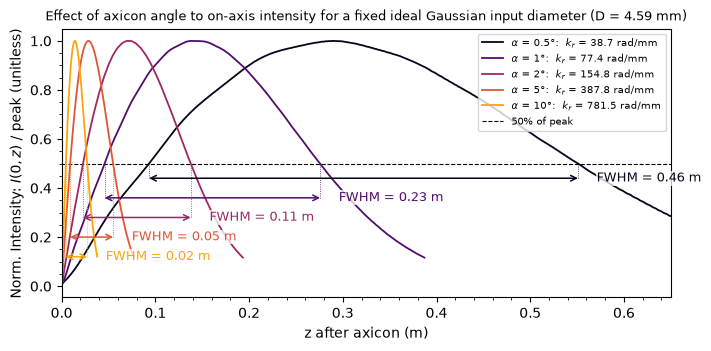

In [146]:
# --- sweep 1: axicon angle (single axicon) -----------------------------------
ANGLES_1AX = (0.5, 1.0, 2.0, 5.0, 10.0)
D_FIX = BASE["GaussianBeamWaist_mm"]

def fwhm_span(z, I):
    """(lo, hi, width) where the curve crosses half its peak."""
    In = I / I.max()
    i = int(np.argmax(In))
    lo_i = np.where(In[:i] < 0.5)[0]          # last sample below half, rising
    hi_i = np.where(In[i:] < 0.5)[0]          # first sample below half, falling
    lo = (np.interp(0.5, [In[lo_i[-1]], In[lo_i[-1] + 1]],
                    [z[lo_i[-1]], z[lo_i[-1] + 1]]) if len(lo_i) else z[0])
    if len(hi_i):
        j = i + hi_i[0]
        hi = np.interp(0.5, [In[j], In[j - 1]], [z[j], z[j - 1]])
    else:
        hi = z[-1]
    return lo, hi, hi - lo


# FWHM dimension arrows: one per curve, staggered in height so the (heavily
# overlapping) spans stay readable; dotted extension lines tie each arrow end
# back to its actual 50% crossing on the curve.
ARROW_Y = (0.44, 0.36, 0.28, 0.20, 0.12)

fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
for a_deg, c, y_arr in zip(ANGLES_1AX, sweep_colors(len(ANGLES_1AX)), ARROW_Y):
    th = deflect(a_deg)
    z_geo = (D_FIX * mm / 2) / th
    z, I, kr = single_axicon_onax(D_FIX, a_deg, 1.35 * z_geo)
    ax.plot(z, I / I.max(), color=c, lw=1.3,
            label=(f"$\\alpha$ = {a_deg:g}°:  $k_r$ = {kr / 1e3:.1f} rad/mm"))
    lo, hi, w = fwhm_span(z, I)
    ax.annotate("", xy=(lo, y_arr), xytext=(hi, y_arr),
                arrowprops=dict(arrowstyle="<->", color=c, lw=1.1,
                                shrinkA=0, shrinkB=0), zorder=4)
    for x_ in (lo, hi):
        ax.plot([x_, x_], [y_arr, 0.5], color=c, lw=0.6, ls=":", zorder=2)
    # label just past the right arrowhead — the spans are nested, so a
    # centered label would sit on top of the neighbouring arrows
    ax.text(hi + 0.02, y_arr, f"FWHM = {w:.2f} m", color=c, fontsize=9, antialiased=True,
            ha="left", va="center", zorder=5,
            bbox=dict(fc="white", ec="none", alpha=0.75, pad=0.8,
                      ))

z_range = np.linspace(0, 1.4, 100)
ax.plot(z_range, [0.5 for _ in z_range], color="black", ls="--", lw=0.8, label="50% of peak", zorder=1)
ax.set_xlabel("z after axicon (m)")
ax.set_ylabel("Norm. Intensity: $I(0,z)$ / peak (unitless)")
ax.set_xlim(0, 0.65)
ax.minorticks_on()
ax.legend(fontsize=7.5, loc="upper right")
ax.set_title(f"Effect of axicon angle to on-axis intensity for a fixed ideal Gaussian input diameter (D = {D_FIX:g} mm)", fontsize=9)
save_fig("theory_single_axicon_angle")
plt.show()


saved images/final_report_theory_2026_08_12/theory_single_axicon_diameter.png


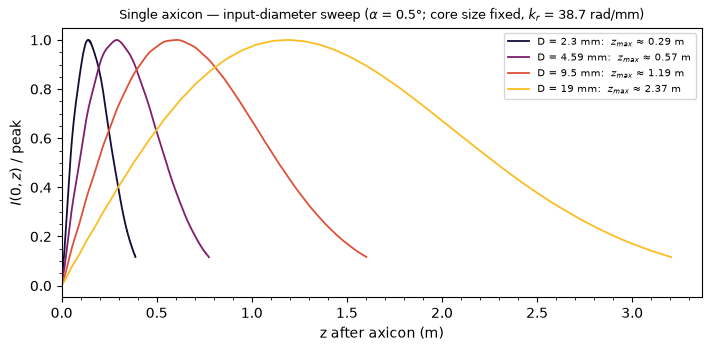

In [112]:
# --- sweep 2: input beam diameter (single axicon) ----------------------------
DIAMS_1AX = (2.3, 4.59, 9.5, 19.0)      # mm; 4.59/9.5 = the two bench beams
A_FIX = 0.5                              # deg, the axicon-3 angle

fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
for D_mm, c in zip(DIAMS_1AX, sweep_colors(len(DIAMS_1AX))):
    th = deflect(A_FIX)
    z_geo = (D_mm * mm / 2) / th
    z, I, kr = single_axicon_onax(D_mm, A_FIX, 1.35 * z_geo)
    ax.plot(z, I / I.max(), color=c, lw=1.3,
            label=f"D = {D_mm:g} mm:  $z_{{max}}$ ≈ {z_geo:.2f} m")
ax.set_xlabel("z after axicon (m)")
ax.set_ylabel("$I(0,z)$ / peak")
ax.set_xlim(0, None)
ax.minorticks_on()
ax.legend(fontsize=7.5, loc="upper right")
ax.set_title(f"Single axicon — input-diameter sweep ($\\alpha$ = {A_FIX:g}°; "
             "core size fixed, $k_r$ = "
             f"{axicon_kr(A_FIX, n=N_GLASS, k=K0) / 1e3:.1f} rad/mm)", fontsize=9)
save_fig("theory_single_axicon_diameter")
plt.show()


## Three-axicon telescope

Axicons 1+2 (equal angles, spacing $L_{12}$) turn the Gaussian into a thin
ring of radius $R_a \\approx (n-1)\\alpha_{1}\\,L_{12}$ and thickness set by
the input beam; axicon 3 folds that ring back onto the axis, making the
Bessel zone at $z \\approx R_a/\\theta_3$ with length $\\approx
\\Delta/\\theta_3$. So: $\\alpha_{1,2}$ and $L_{12}$ move the zone (via the
ring radius), $D$ stretches it (ring thickness), and $\\alpha_3$ trades
zone position/length against core size ($k_{r3} = k(n-1)\\alpha_3$).
Each sweep below runs the full QDHT chain via `simulate_recorded_optic`.

In [113]:
# --- three-axicon sweep machinery --------------------------------------------
def ring_radius_mm(optic):
    return deflect(optic["Axicon1_deg"]) * optic["L12_mm"]


def sweep_three_axicon(param, values, ax, fmt, note=""):
    for v, c in zip(values, sweep_colors(len(values))):
        optic = dict(BASE)
        if param == "a12":
            optic["Axicon1_deg"] = optic["Axicon2_deg"] = v
        elif param == "a3":
            optic["Axicon3_deg"] = v
        elif param == "D":
            optic["GaussianBeamWaist_mm"] = v
        elif param == "L12":
            optic["L12_mm"] = v
        _, model = simulate_recorded_optic(optic, N=4096, Nz2=40, Nz3=300,
                                           verbose=False)
        z3, I3 = model["z3"], model["onax"]
        # normalize to the BESSEL-ZONE peak (z > 0.5 R_a/theta3), same idea
        # as the webapp's window logic — the near-axicon fringes can exceed
        # the zone peak and would otherwise flatten the interesting region
        z_zone = (ring_radius_mm(optic) * mm
                  / deflect(optic["Axicon3_deg"]))
        m_ = np.isfinite(I3) & (z3 > 0.5 * z_zone)
        if not m_.any():      # model grid never reached the zone: skip
            print(f"NOTE {param}={v:g}: model z-grid ends before the zone "
                  f"(~{z_zone:.2f} m) — curve skipped")
            continue
        pk = I3[m_].max()
        ax.plot(z3, I3 / pk, color=c, lw=1.3, label=fmt(v, optic))
    ax.set_xlabel("z after axicon 3 (m)")
    ax.set_ylabel("$I(0,z)$ / zone peak")
    ax.set_xlim(0, None)
    ax.set_ylim(0, 1.12)     # near-axicon fringes may exceed the zone peak
    ax.minorticks_on()
    ax.legend(fontsize=7.5, loc="upper right")



saved images/final_report_theory_2026_08_12/theory_three_axicon_a12.png


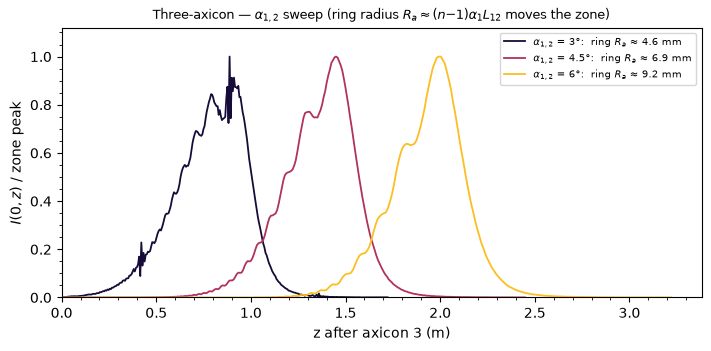

In [114]:
# --- sweep 3: axicon 1/2 angle -----------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
# sweep limits: below ~2 deg the cones still overlap at axicon 2 (no clean
# annulus, L12 < 1.2 zmax — the simulator asserts) and the small ring makes
# a short, messy zone; above ~6 deg the N=4096 radial grid no longer
# resolves the axicon fringes (asserts too).
sweep_three_axicon("a12", (3.0, 4.5, 6.0), ax,
    lambda v, o: (f"$\\alpha_{{1,2}}$ = {v:g}°:  ring $R_a$ ≈ "
                  f"{ring_radius_mm(o):.1f} mm"))
ax.set_title("Three-axicon — $\\alpha_{1,2}$ sweep (ring radius "
             "$R_a \\approx (n{-}1)\\alpha_1 L_{12}$ moves the zone)",
             fontsize=9)
save_fig("theory_three_axicon_a12")
plt.show()


saved images/final_report_theory_2026_08_12/theory_three_axicon_a3.png


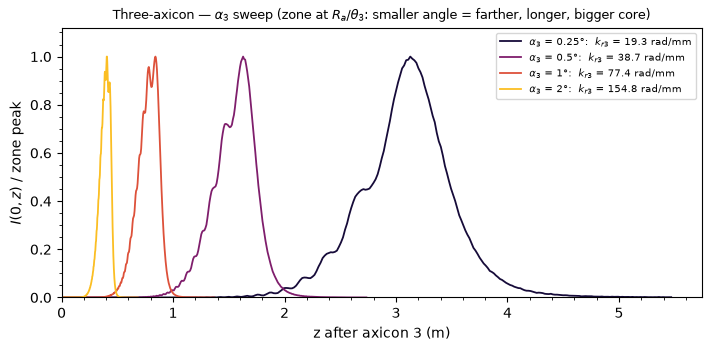

In [115]:
# --- sweep 4: axicon 3 angle -------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
sweep_three_axicon("a3", (0.25, 0.5, 1.0, 2.0), ax,
    lambda v, o: (f"$\\alpha_3$ = {v:g}°:  $k_{{r3}}$ = "
                  f"{axicon_kr(v, n=N_GLASS, k=K0) / 1e3:.1f} rad/mm"))
ax.set_title("Three-axicon — $\\alpha_3$ sweep (zone at $R_a/\\theta_3$: "
             "smaller angle = farther, longer, bigger core)", fontsize=9)
save_fig("theory_three_axicon_a3")
plt.show()


saved images/final_report_theory_2026_08_12/theory_three_axicon_D.png


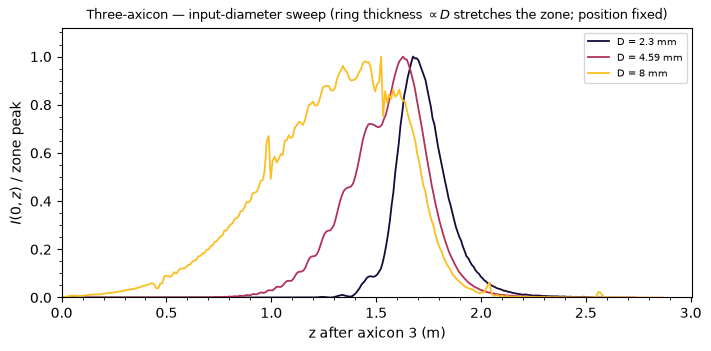

In [116]:
# --- sweep 5: input beam diameter --------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
# D=9.44 mm (the candidate-#2 beam) breaks the model at THIS baseline: with
# L23 = 50 mm the beam cones barely separate before axicon 2 (zmax = 118 mm
# vs L12 = 190) and the z-grid heuristic collapses. It worked for candidate
# #2 because that geometry used L12 = 240 / L23 = 220. Sweep to 8 mm here.
sweep_three_axicon("D", (2.3, 4.59, 8.0), ax,
    lambda v, o: f"D = {v:g} mm")
ax.set_title("Three-axicon — input-diameter sweep (ring thickness "
             "$\\propto D$ stretches the zone; position fixed)", fontsize=9)
save_fig("theory_three_axicon_D")
plt.show()


saved images/final_report_theory_2026_08_12/theory_three_axicon_L12.png


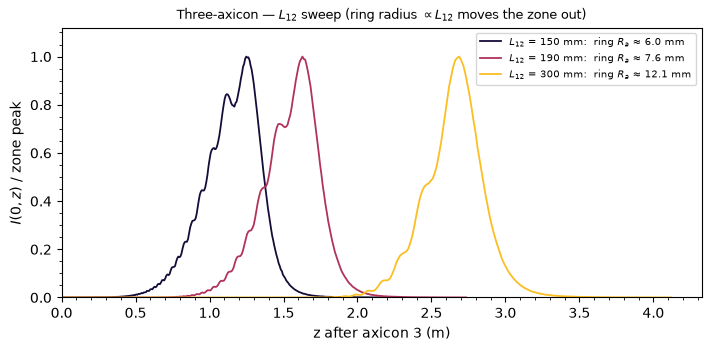

In [117]:
# --- sweep 6: L12 spacing ----------------------------------------------------
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
# L12=100 mm is out of the model's reach with the 50 mm L23 baseline (the
# ring FWHM measurement at axicon 3 fails -> NaN z-grid), so start at 150.
sweep_three_axicon("L12", (150.0, 190.0, 300.0), ax,
    lambda v, o: (f"$L_{{12}}$ = {v:g} mm:  ring $R_a$ ≈ "
                  f"{ring_radius_mm(o):.1f} mm"))
ax.set_title("Three-axicon — $L_{12}$ sweep (ring radius "
             "$\\propto L_{12}$ moves the zone out)", fontsize=9)
save_fig("theory_three_axicon_L12")
plt.show()
